In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from wordcloud import WordCloud
from collections import Counter
from sklearn.metrics import silhouette_score
from sentence_transformers import SentenceTransformer
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import normalize, Normalizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.preprocessing import FunctionTransformer
from sklearn.pipeline import Pipeline
import random
import warnings
import os
import services.utils as ut
import services.model as md
np.random.seed(42)
random.seed(42)

ModuleNotFoundError: No module named 'services'

In [2]:
warnings.filterwarnings('ignore', category=UserWarning)
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ['TRANSFORMERS_VERBOSITY'] = 'error'

In [3]:
data_df = ut.load_data('customer_support_tickets.csv')
if data_df is not None:
    print("Data loaded successfully")
print(data_df.head())

NameError: name 'ut' is not defined

## Preprocessing

In [ ]:
data_df = data_df.drop_duplicates(subset=['Ticket Description'], keep='first')
data_df.reset_index(drop=True, inplace=True)

In [ ]:
data_df['text'] = data_df['Ticket Description'].fillna('')

In [ ]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'\{.*?\}', '', text)
    text = re.sub(r'http\S+', '', text) # remove URLs
    text = re.sub(r'[^a-z\s]', '', text)
    text = re.sub(r'\b[a-zA-Z]{1,2}\b', '', text)  # remove very short words
    return text

data_df['clean_text'] = data_df['text'].apply(clean_text)
data_df['clean_text'].head()

0     having  issue with the  please assist\n\nyour...
1     having  issue with the  please assist\n\n you...
2     facing  problem with   the   not turning   wa...
3     having  issue with the  please assist\n\n you...
4     having  issue with the  please assist\n\n\nno...
Name: clean_text, dtype: str

In [ ]:
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

[nltk_data] Downloading package punkt to /Users/liyannan/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/liyannan/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/liyannan/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [ ]:
custom_words = {
    'please', 'help', 'assist', 'support', 'thanks', 'thank','soon','mentioned',
    'im', 'ive', 'us','would', 'could', 'need', 'want', 'trying',
    'tried','check', 'checked', 'make', 'made', 'get', 'getting','also',
    'use', 'using', 'used','thing', 'something', 'anything', 'everything',
    'way', 'time','issue', 'problem', 'request',
    'work', 'working', 'fine', 'available', 'recent', 'recently','facing', 'doe',
    'noticed', 'happening', 'started', 'happen','different', 'steps', 'did',
    'regards','already', 'multiple','last','times','followed', 'reviewed',
    'specific', 'possible', 'related','new', 'old','find', 'try', 'trying', 'say', 'mean',
    'name', 'email', 'price', 'one', 'add','note', 'may', 'dont', 'know','sure',
    'changes', 'performed', 'properly','original','like', 'similar','reported','doesnt',
    'sometimes', 'acts', 'works', 'ensure', 'desired', 'action', 'remains', 'life', 'seems',
    'might', 'guide', 'much', 'others',
    'heavily', 'daily', 'task',
    'affecting', 'assistance',
    'hoping','persists','didnt',
    'option', 'perform', 'recommendation', 'information', 'official',
    'solution', 'provide', 'making',
    'user', 'customer',
    'item', 'device',
    'far', 'luck','contact', 'contacted', 'occurring'
}

In [ ]:
custom_words_lemma = set([lemmatizer.lemmatize(w) for w in custom_words])

def preprocess(text):
    tokens = word_tokenize(text)
    
    processed_tokens = []
    
    for word in tokens:
        lemma = lemmatizer.lemmatize(word)
        
        if lemma not in stop_words and lemma not in custom_words_lemma and len(lemma) > 2:
            processed_tokens.append(lemma)
    
    return " ".join(processed_tokens)

data_df['processed_text'] = data_df['clean_text'].apply(preprocess)

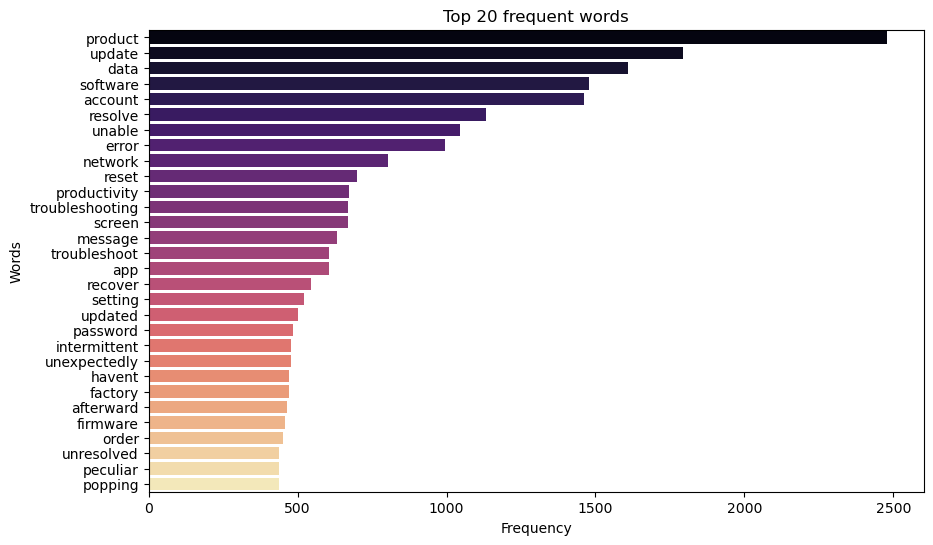

In [ ]:
text_data = data_df['processed_text'].astype(str)

all_words = " ".join(text_data).lower().split()
common_words = Counter(all_words).most_common(30)

words, counts = zip(*common_words)

plt.figure(figsize=(10,6))
sns.barplot(x=list(counts), y=list(words), hue=list(words), palette='magma', legend=False)
plt.title("Top 20 frequent words")
plt.xlabel("Frequency")
plt.ylabel("Words")
plt.show()

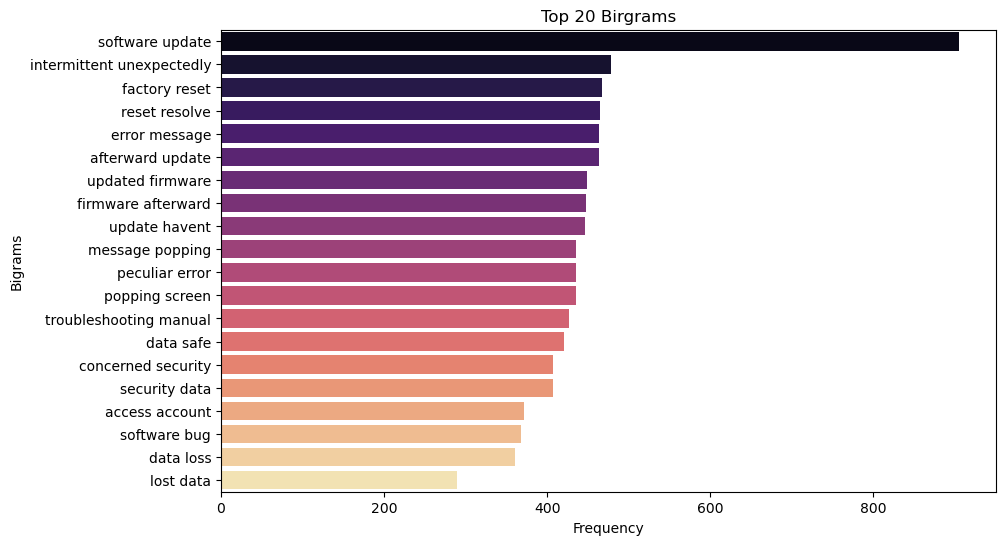

In [ ]:
vectorizer = CountVectorizer(ngram_range=(2,2), stop_words='english')
x = vectorizer.fit_transform(data_df['processed_text'])
word_counts = x.sum(axis=0).A1
words = vectorizer.get_feature_names_out()
word_freq = list(zip(words, word_counts))
word_freq = sorted(word_freq, key=lambda x: x[1], reverse=True)[:20]
words, counts = zip(*word_freq)

plt.figure(figsize=(10,6))
sns.barplot(x=list(counts), y=list(words), hue=list(words), palette='magma')
plt.title("Top 20 Birgrams")
plt.xlabel("Frequency")
plt.ylabel("Bigrams")
plt.show()

In [ ]:
ut.save_data(data_df, 'cleaned_data.csv')

Building the pipeline

In [ ]:
def nlp_cleaner(text_list):
    results = []
    for text in text_list:
        cleaned = clean_text(text) 
        processed = preprocess(cleaned)
        results.append(processed)
    return results

### TFIDF

In [ ]:
tfidf = TfidfVectorizer(max_features=1000,ngram_range=(1,2),min_df=5,max_df=0.7)

X = tfidf.fit_transform(data_df['processed_text'])

In [ ]:
tfidf__preprocessing_pipeline = Pipeline([
    ('cleaner', FunctionTransformer(nlp_cleaner, validate=False)),
    ('tfidf', TfidfVectorizer(max_features=1000,ngram_range=(1,2),min_df=5,max_df=0.7))
])

### Embeddings

In [ ]:
def clean_for_embeddings(text):
    text = text.lower()
    text = re.sub(r'\{.*?\}', ' ', text)
    text = re.sub(r'http\S+', ' ', text)
    text = re.sub(r"i'?m having an issue with.*?please assist\.?", ' ', text)
    text = re.sub(r'please assist\.?', ' ', text)
    text = re.sub(r'\b(id|created_at|product|price)\b', ' ', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

In [ ]:
data_df['embedding_text'] = data_df['text'].apply(clean_for_embeddings)

In [ ]:
model = SentenceTransformer('all-MiniLM-L6-v2')

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
embeddings = model.encode(data_df['embedding_text'].tolist(), show_progress_bar=True)

Batches:   0%|          | 0/253 [00:00<?, ?it/s]

In [ ]:
embeddings = normalize(embeddings)

In [ ]:
print(cosine_similarity([embeddings[0]], [embeddings[1]]))
print(cosine_similarity([embeddings[2]], [embeddings[5]]))

[[0.33734772]]
[[0.6662934]]


Building the pipeline

In [ ]:
def nlp_cleaner_embeddings(text_list):
    results = []
    for text in text_list:
        cleaned = clean_for_embeddings(text) 
        results.append(cleaned)
    return results

In [2]:
embedding_preprocessing_pipeline = Pipeline([
    ('cleaner', FunctionTransformer(nlp_cleaner_embeddings, validate=False)),
    ('embeddings', md.SentenceEmbeddingTransformer(model_name='all-MiniLM-L6-v2')),
    ('normalize', Normalizer())
])

NameError: name 'nlp_cleaner_embeddings' is not defined

## Modelling

## Kmeans with TFIDF

## TF-IDF + HAC（Yannan Li)
In this section, we apply Hierarchical Agglomerative Clustering (HAC) to the TF-IDF representation of the processed ticket descriptions. This allows us to compare a hierarchical clustering approach with the KMeans baseline and assess whether HAC produces more interpretable groups of customer issues.

注意：移除了 21 条全 0 向量的样本（可能是由于文本过短或词汇被过滤）。
数据修复完成，开始 HAC 稳定性分析...
正在运行 HAC 稳定性分析...
k=2: Silhouette Score = 0.0262
k=3: Silhouette Score = 0.0281
k=4: Silhouette Score = 0.0355
k=5: Silhouette Score = 0.0387
k=6: Silhouette Score = 0.0430
k=7: Silhouette Score = 0.0446
k=8: Silhouette Score = 0.0558
k=9: Silhouette Score = 0.0691
k=10: Silhouette Score = 0.0755


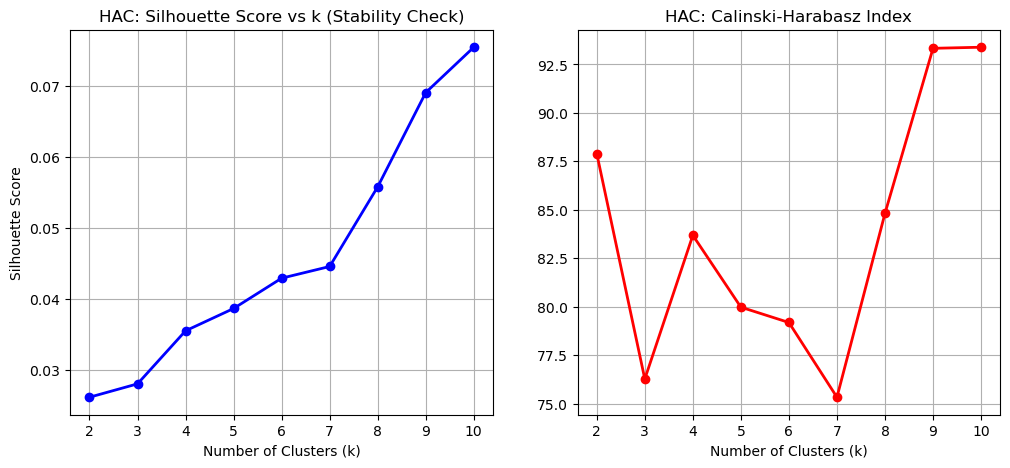

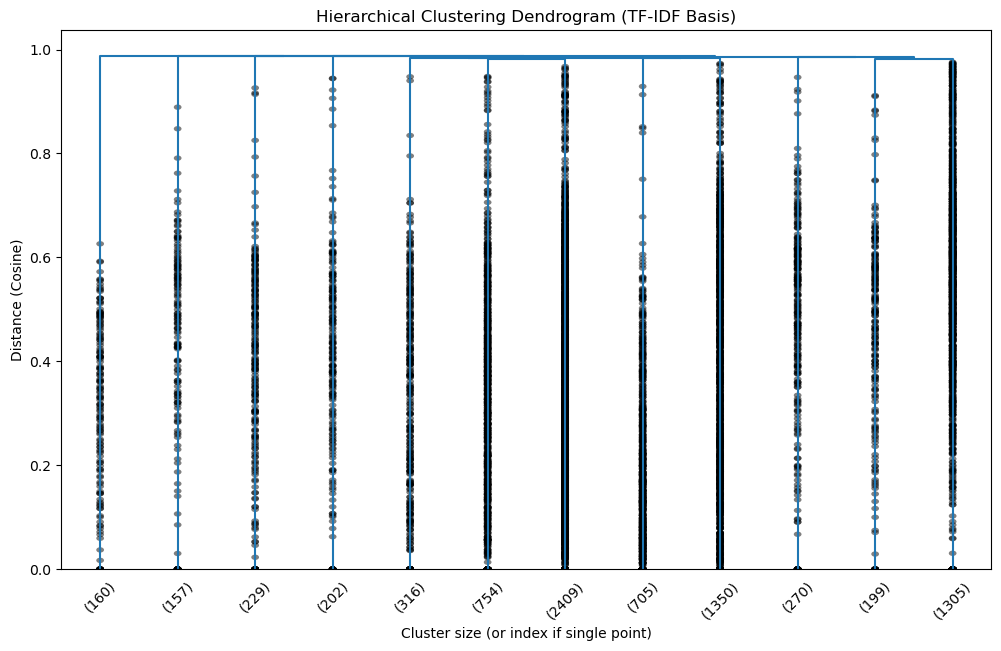


每个 HAC 簇的主题关键词:
Cluster 0: product, update, software, data, account, unable, resolve, software update, productivity, troubleshooting
Cluster 1: consistently, consistently feature, feature application, occurs consistently, occurs, feature, application, click, brand, product
Cluster 2: charging, came charging, charger came, charger, came, product, order, true, purchase, purchased
Cluster 3: require repair, repair replacement, hardwarerelated require, worried hardwarerelated, hardwarerelated, require, worried, repair, replacement, product
Cluster 4: battery, longer, sudden, sudden decrease, decrease battery, battery longer, decrease, product, image, define


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score, calinski_harabasz_score
from scipy.cluster.hierarchy import dendrogram, linkage

# 1. Prepare data: HAC typically requires handling dense matrices.
# Note: X is a sparse matrix generated by tfidf.fit_transform.
X_dense = X.toarray()

# 1. Find the row indices of all non-zero vectors.
# np.any(X_dense ! The function (np.where(result == 0, True, False), axis=1) will return a boolean array indicating which rows contain non-zero values.
non_zero_indices = np.any(X_dense != 0, axis=1)

# 2. 统Count the number of rows that have been removed (used to explain the data cleaning process in the report)
removed_count = len(X_dense) - np.sum(non_zero_indices)
print(f"Attention：Removed {removed_count} samples consisting entirely of zeros.")

# 3. Filtering matrix and original DataFrame

X_dense = X_dense[non_zero_indices]
data_df = data_df.iloc[np.where(non_zero_indices)[0]].reset_index(drop=True)

print("Data repair is complete. Now starting HAC stability analysis....")

# 4. Stability analysis (Investigate stability across k) [cite: 102]

hac_sil_scores = []
hac_ch_scores = []
k_range = range(2, 11)

print("The HAC stability analysis is currently in progress....")

for k in k_range:
    #For text data, 'cosine' (cosine distance) is more effective than Euclidean distance in measuring topic similarity [cite: 108]
    # Using 'average' linkage usually results in more balanced clusters.
    hac = AgglomerativeClustering(n_clusters=k, metric='cosine', linkage='average')
    labels = hac.fit_predict(X_dense)
    
    # Calculate the evaluation indicators [cite: 110]
    sil = silhouette_score(X_dense, labels, metric='cosine')
    ch = calinski_harabasz_score(X_dense, labels)
    
    hac_sil_scores.append(sil)
    hac_ch_scores.append(ch)
    print(f"k={k}: Silhouette Score = {sil:.4f}")

# 5. Visualization of stability analysis results
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(k_range, hac_sil_scores, 'bo-', linewidth=2)
plt.title('HAC: Silhouette Score vs k (Stability Check)')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(k_range, hac_ch_scores, 'ro-', linewidth=2)
plt.title('HAC: Calinski-Harabasz Index')
plt.xlabel('Number of Clusters (k)')
plt.grid(True)
plt.show()

# 6. Draw a dendrogram(Dendrogram)
# The tree diagram can visually illustrate how the themes in customer feedback are hierarchically merged [cite: 101]
plt.figure(figsize=(12, 7))
plt.title("Hierarchical Clustering Dendrogram (TF-IDF Basis)")

# Perform hierarchical association calculation using scipy's linkage function
Z = linkage(X_dense, method='average', metric='cosine')

dendrogram(
    Z,
    truncate_mode='lastp', # Only display the last p merged nodes to avoid the chart from becoming too crowded.
    p=12,
    leaf_rotation=45.,
    leaf_font_size=10.,
    show_contracted=True
)
plt.xlabel("Cluster size (or index if single point)")
plt.ylabel("Distance (Cosine)")
plt.show()

# 7. Extract the final clusters and generate Actionable Insights [cite: 96]
# Based on the above chart, select a k value that shows relatively stable performance ( k = 5)
best_hac_k = 5
final_hac_model = AgglomerativeClustering(n_clusters=best_hac_k, metric='cosine', linkage='average')
data_df['HAC_Cluster'] = final_hac_model.fit_predict(X_dense)

# 8. Explanation of clustering(Interpretability of issue categories) [cite: 112]
print("\n每个 HAC 簇的主题关键词:")
# Obtain the bag-of-words feature names from the defined tfidf variable
terms = tfidf.get_feature_names_out()

for i in range(best_hac_k):
    # Calculate the average value (centroid) of all the document vectors within this cluster to identify the representative words.
    cluster_indices = data_df[data_df['HAC_Cluster'] == i].index
    if len(cluster_indices) > 0:
        # 
        cluster_vecs = X_dense[data_df.index.get_indexer(cluster_indices)]
        centroid = cluster_vecs.mean(axis=0)
        # Obtain the 10 words with the highest weights
        top_indices = centroid.argsort()[-10:][::-1]
        top_words = [terms[idx] for idx in top_indices]
        print(f"Cluster {i}: {', '.join(top_words)}")

虽然轮廓系数较低，这反映了文本数据固有的重叠性和高维稀疏性。然而，聚类结果是否有效，更应结合关键词的可解释性（Interpretability）来衡量。

K值为什么选择5？
客户服务工单（Tickets），通常核心类别包括：技术故障、退款/账单、产品咨询、物流/快递、账号安全。如果 k值 太大（如 10 以上），会导致很多小簇（例如只有一个样本），失去聚类分析的意义。
